# Sleep-EDF 数据集入门

### 文件

每个受试者的每晚记录通常由两个文件组成（例如 SC4001E0-PSG.edf 和 SC4001E0-Hypnogram.edf）

1. PSG 文件 (-PSG.edf):

PolySomnoGraphy，多导睡眠图。这是主要的生理信号数据文件。

它包含了多个生理通道的原始数据，最重要的通常是：

- EEG (脑电图): 通常有 1-4 个通道，例如 EEG Fpz-Cz (额中-中央导联) 和 EEG Pz-Oz (顶骨-枕骨导联)。这些是睡眠分期的主要依据。

- EOG (眼电图): EOG horizontal (水平眼电) 和 EOG vertical (垂直眼电或仅单通道)。用于检测眼动，特别是REM睡眠。

- EMG (肌电图): EMG submental (下颌肌电)。用于检测肌肉张力，特别是用于区分清醒、REM和非REM睡眠。

- 其他通道: 有时可能包含心电图 (ECG)、呼吸信号 (Respiration)、腿部运动 (Leg movement) 等，但在睡眠分期中不是核心。

2. Hypnogram 文件 (-Hypnogram.edf):

Hypnogram 是睡眠分期图。这个文件包含了专家对PSG文件中每30秒（一个epoch）的睡眠阶段标注。

它通常只有一个数据通道，通道名为 Annotation 或类似名称。

每个数据点代表一个30秒的epoch，其值是一个整数或字符串，对应不同的睡眠阶段。

- W: 清醒 (Wake)
- N1: 非REM睡眠第一阶段
- N2: 非REM睡眠第二阶段
- N3: 非REM睡眠第三阶段 (深度睡眠，有时也称为SWS - Slow Wave Sleep)
- REM: 快速眼动睡眠 (Rapid Eye Movement)
- MT: 身体运动 (Movement Time)
- ? / UNK: 未知或未分期

其中文件内

- Sleep stage W → Wake（W）
- Sleep stage 1 → N1
- Sleep stage 2 → N2
- Sleep stage 3 / Sleep stage 4 → N3（AASM 标准将 3+4 合并为 N3；老的 R&K 标准区分 3 和 4）
- Sleep stage R → REM（R）
- Sleep stage ? → 未知/UNK

### Epoch

关键概念：Epoch （时段）

睡眠分期是基于30秒一个时段（epoch）进行的。这意味着：

- PSG文件中的信号需要被切分成30秒的片段。
- 每个30秒片段对应Hypnogram文件中的一个标注。
- 模型将接收一个30秒的EEG（或其他生理）信号片段作为输入，然后输出一个睡眠阶段类别。

### 数据可视化与快速理解

使用 Python 中的 mne 库（MEG/EEG S/P Package）来处理 EDF 文件，它对神经生理数据处理较好。

Extracting EDF parameters from ./sleep-edf/sleep-cassette/SC4071E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 8429999  =      0.000 ... 84299.990 secs...


C:\Users\Eason\AppData\Local\Temp\ipykernel_42916\1605510596.py:17: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_psg = mne.io.read_raw_edf(psg_file, preload=True)
C:\Users\Eason\AppData\Local\Temp\ipykernel_42916\1605510596.py:17: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_psg = mne.io.read_raw_edf(psg_file, preload=True)
C:\Users\Eason\AppData\Local\Temp\ipykernel_42916\1605510596.py:17: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw_psg = mne.io.read_raw_edf(psg_file, preload=True)



--- PSG 文件信息 ---
<RawEDF | SC4071E0-PSG.edf, 7 x 8430000 (84300.0 s), ~450.2 MiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: unspecified
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 30yr>
>

通道名称: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
采样频率: 100.0 Hz
记录时长: 84299.99 秒

找到的EEG通道: ['EEG Fpz-Cz', 'EEG Pz-Oz']
找到的EOG通道: ['EOG horizontal']
找到的EMG通道: ['EMG submental']
[[ 6.44517705e-06]
 [ 6.44517705e-06]
 [ 1.77313797e-05]
 ...
 [-2.07216117e-05]
 [-1.95230769e-05]
 [-1.98227106e-05]]


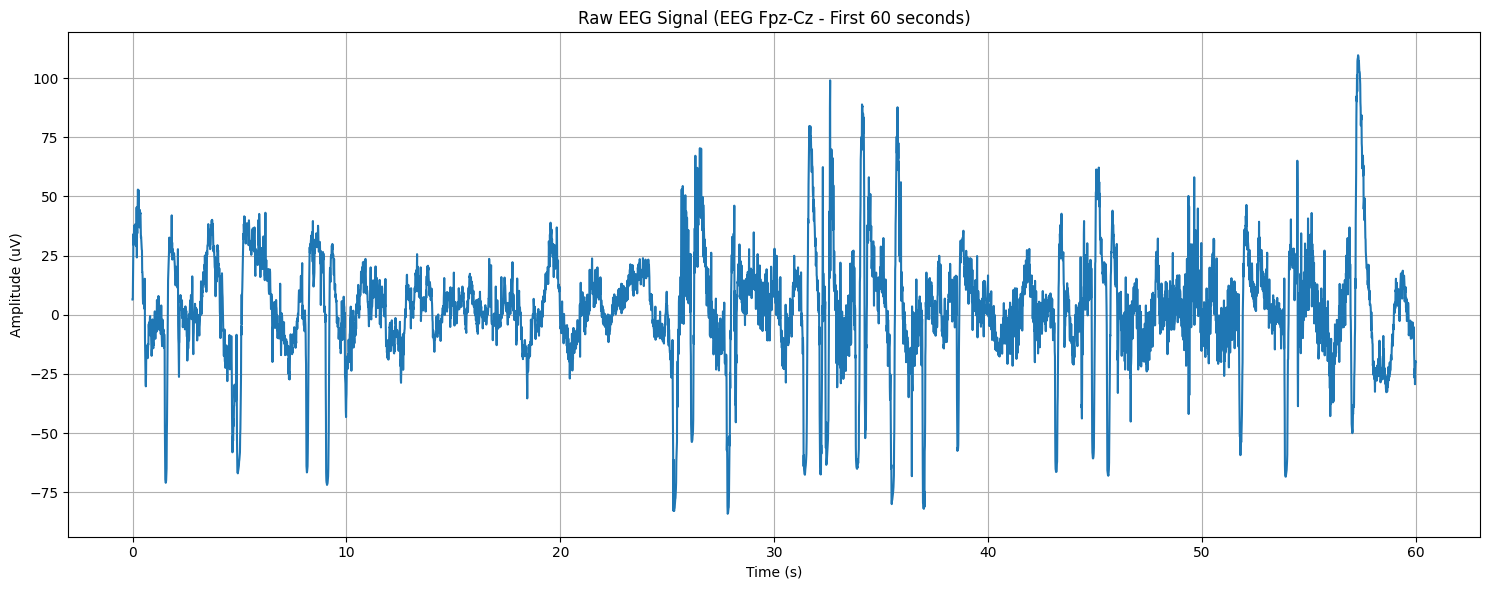

In [46]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # 用于处理标注数据

# --- 1. 下载数据 ---
# MNE本身提供了下载Sleep-EDF的便捷函数
# 受试者的PSG和Hypnogram文件 https://www.physionet.org/content/sleep-edfx/1.0.0/sleep-cassette/
# 下载 SC4001E0-PSG.edf 和 SC4001E0-Hypnogram.edf 到工作目录


psg_file = './sleep-edf/sleep-cassette/SC4071E0-PSG.edf'
hyp_file = './sleep-edf/sleep-cassette/SC4071EC-Hypnogram.edf'

# --- 2. 加载 PSG 文件 (生理信号数据) ---

raw_psg = mne.io.read_raw_edf(psg_file, preload=True)
raw_psg.set_meas_date(None) # 有时MNE会抱怨没有测量日期，设为None以避免警告
print("\n--- PSG 文件信息 ---")
print(raw_psg)
print(raw_psg.info)
print("\n通道名称:", raw_psg.ch_names)
print("采样频率:", raw_psg.info['sfreq'], "Hz")
print("记录时长:", raw_psg.times[-1], "秒")

# 尝试提取常用的EEG通道和EOG、EMG
eeg_channels = [ch for ch in raw_psg.ch_names if 'EEG' in ch.upper()]
eog_channels = [ch for ch in raw_psg.ch_names if 'EOG' in ch.upper()]
emg_channels = [ch for ch in raw_psg.ch_names if 'EMG' in ch.upper()]

print("\n找到的EEG通道:", eeg_channels)
print("找到的EOG通道:", eog_channels)
print("找到的EMG通道:", emg_channels)

# 绘制部分原始EEG信号
plt.figure(figsize=(15, 6))
if eeg_channels: # 确保有EEG通道
    # 只绘制第一个EEG通道，前60秒数据
    eeg_data, times = raw_psg[eeg_channels[0], 0:int(raw_psg.info['sfreq']*60)] 
    print(eeg_data.T)
    plt.plot(times, eeg_data.T * 1e6) # 乘以1e6转换为微伏（uV）
    plt.title(f'Raw EEG Signal ({eeg_channels[0]} - First 60 seconds)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (uV)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()



<Annotations | 116 segments: Sleep stage 1 (23), Sleep stage 2 (33), Sleep ...>

--- Hypnogram 标注信息 ---
找到 116 条标注事件。

--- 部分睡眠标注 (Hypnogram) ---
                onset  duration    description
0 1970-01-01 00:00:00   27990.0  Sleep stage W
1 1970-01-01 07:46:30     660.0  Sleep stage 1
2 1970-01-01 07:57:30     270.0  Sleep stage 2
3 1970-01-01 08:02:00      60.0  Sleep stage 1
4 1970-01-01 08:03:00     510.0  Sleep stage 2


C:\Users\Eason\AppData\Local\Temp\ipykernel_42916\1551093571.py:13: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_psg.set_annotations(annotations_hyp)


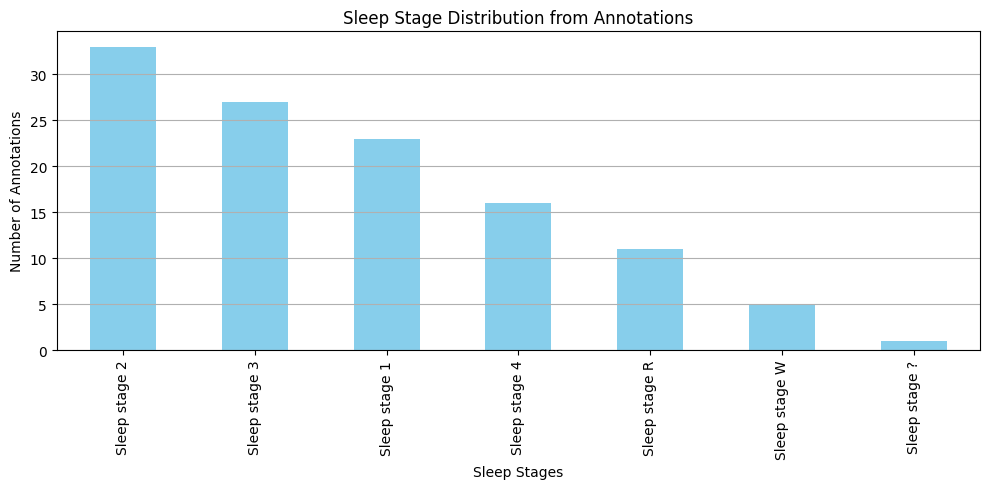

In [47]:
# --- 3. 加载 Hypnogram 文件 (睡眠阶段标注) ---
# 对于 Sleep-EDF 数据集，Hypnogram.edf 文件通常是MNE可以识别的特殊标注文件
# 而不是普通的raw信号文件，所以不应使用 read_raw_edf
# 而是使用 read_annotations()
try:
    annotations_hyp = mne.read_annotations(hyp_file)
    print(annotations_hyp)
    print("\n--- Hypnogram 标注信息 ---")
    print(f"找到 {len(annotations_hyp)} 条标注事件。")
    print("\n--- 部分睡眠标注 (Hypnogram) ---")
    print(annotations_hyp.to_data_frame().head())
    # 将标注应用到PSG raw数据中
    raw_psg.set_annotations(annotations_hyp)
except Exception as e:
    print(f"加载 Hypnogram 文件出错: {e}")
    # 尝试作为EDF文件读取，并从中解析标注 (Less common for Sleep-EDF)
    try:
        raw_hyp_special = mne.io.read_raw_edf(hyp_file, preload=True)
        raw_hyp_special.set_meas_date(None) # 解决MNE版本问题
        print("\n--- Hypnogram (作为RawEDF) 文件信息 ---")
        print(raw_hyp_special.info)
        # 假设标注信息在某个通道的值中，这需要根据具体文件设计来解析
        # 比如，如果有一个名为'Sleep stage'的通道，其值代表睡眠阶段编码
        # 但对于Sleep-EDF来说，read_annotations()几乎总是正确的做法
        
        # 尝试从处理过的 raw_hyp_special 中创建 MNE 注解
        # 这通常会涉及将通道值映射到具体的睡眠阶段描述
        # 举例: 如果有一个通道 'Annotation' 包含整数编码
        # events, event_dict = mne.events_from_annotations(raw_hyp_special)
        # raw_psg.set_annotations(mne.annotations_from_events(events, raw_psg.info['sfreq'], event_dict))
        print("警告: read_annotations() 失败，尝试以特殊EDF模式读取，但可能还需要手动转换通道数据为标注。")
        print("请检查 Hypnogram.edf 的实际内容和结构。")
        
        # 在这里，我们再次尝试将读到的（如果read_raw_edf成功）annotations应用到raw_psg,虽然上面已经做过
        # 如果read_annotations()失败，raw_psg的annotations可能为空。
        # 如果 raw_hyp_special 本身就有 MNE 可识别的 annotations，也可以尝试：
        # raw_psg.set_annotations(raw_hyp_special.annotations)
        # 或者，更常见的是，raw_hyp_special 的“通道”数据实际上就是睡眠阶段的编码。
        # MNE 提供了一个更方便的函数 `mne.read_events()` 或 `mne.events_from_annotations()` 来处理这类EDF文件。
        
        # 对于 Sleep-EDF 数据集，可以直接从Annotations中获取
        # 假设 raw_psg 的 annotations 已经被设置
        
    except Exception as e_second:
        print(f"第二次尝试加载 Hypnogram 文件也失败了: {e_second}")
        print("请确保 Hypnogram.edf 文件存在且未损坏，并且MNE版本兼容。")
# 假设 raw_psg 的 annotations 已经被正确设置 (通过上面 `raw_psg.set_annotations(annotations_hyp)`)
# 这一步是提取事件和映射睡眠阶段的关键。
if raw_psg.annotations:
    # 可视化睡眠阶段分布
    stage_names = raw_psg.annotations.description
    stage_counts = pd.Series(stage_names).value_counts()
    plt.figure(figsize=(10, 5))
    stage_counts.plot(kind='bar', color='skyblue')
    plt.title('Sleep Stage Distribution from Annotations')
    plt.xlabel('Sleep Stages')
    plt.ylabel('Number of Annotations')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()   


In [48]:
# if raw_psg.annotations:    
#     sleep_stages_events, event_id = mne.events_from_annotations(raw_psg, event_id='auto')
#     # print(sleep_stages_events)
#     # event_id 现在会包含类似 {'Sleep stage W': 1, 'Sleep stage 1': 2, ...} 的映射
#     print(f"\n睡眠阶段事件ID映射: {event_id}")
#     # 将事件转换为30秒epoch的标注
#     epochs = []
#     labels = []
    
#     # 键值对反转
#     stage_to_id = {v: k for k, v in event_id.items()} # 反向映射以便查找阶段名称
#     # 这里需要遍历 events，并根据 duraion 进行判断
#     for event_idx, event_type in enumerate(sleep_stages_events[:, 2]):

#         # 获取原始 Annotation 对象的持续时间
#         duration_from_annotation = raw_psg.annotations[event_idx]['duration']
#         start_sample = sleep_stages_events[event_idx, 0]
#         duration_samples = int(raw_psg.annotations[event_idx]['duration'] * raw_psg.info['sfreq'])
        
#         # print(duration_samples)
#         # print(raw_psg.info['sfreq'])
#         # 对于 Sleep-EDF，一个标注的duration通常就是30秒
#         # 如果不是30秒，需要决定如何处理（比如，跳过，或者截断，或者填充）
#         if duration_samples / raw_psg.info['sfreq'] == 30.0:
#             stage_name = stage_to_id.get(event_type, 'Unknown')
#             epochs.append({'start_sample': start_sample, 'end_sample': start_sample + duration_samples, 'stage': stage_name})
#             labels.append(stage_name)
    
#     print(f"\n提取了 {len(epochs)} 个30秒睡眠阶段标注。")
#     print("前10个睡眠阶段:", [e['stage'] for e in epochs[:10]])
#     print(epochs)

#     # 可视化睡眠阶段分布
#     stage_names = list(event_id.keys())
#     stage_counts = [labels.count(name) for name in stage_names]
#     plt.figure(figsize=(10, 5))
#     plt.bar(stage_names, stage_counts, color='skyblue')
#     plt.title('Sleep Stage Distribution')
#     plt.xlabel('Sleep Stages')
#     plt.ylabel('Number of Epochs (30s each)')
#     plt.grid(axis='y')
#     plt.tight_layout()
#     plt.show()
    
# else:
#     print("警告: 未能从 Hypnogram 文件中加载有效标注，无法提取睡眠阶段。")

Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage ?'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]

睡眠阶段事件ID映射: {np.str_('Sleep stage 1'): 1, np.str_('Sleep stage 2'): 2, np.str_('Sleep stage 3'): 3, np.str_('Sleep stage 4'): 4, np.str_('Sleep stage ?'): 5, np.str_('Sleep stage R'): 6, np.str_('Sleep stage W'): 7}

提取了 65 个30秒睡眠阶段标注。

前10个睡眠阶段: [np.str_('Sleep stage 3'), np.str_('Sleep stage 2'), np.str_('Sleep stage 4'), np.str_('Sleep stage 3'), np.str_('Sleep stage 3'), np.str_('Sleep stage W'), np.str_('Sleep stage 4'), np.str_('Sleep stage 3'), np.str_('Sleep stage 3'), np.str_('Sleep stage 1')]

[{'start_sample': np.int64(3114000), 'end_sample': np.int64(3117000), 'stage': np.str_('Sleep stage 3')}, {'start_sample': np.int64(3117000), 'end_sample': np.int64(3120000), 'stage': np.str_('Sleep stage 2')}, ...]


--- 处理Annotations ---

收集到 2810 个 30 秒的有效睡眠阶段epochs。
总有效标注时长: 84300.00 秒。
实际处理的有效epoch总时长: 84300.00 秒。
因标注过短或碎片化而被丢弃的有效标注数据比例: 0.00%

前5个收集到的epoch参数示例:
{'start_sample': 0, 'end_sample': 3000, 'stage': 'Sleep stage W'}
{'start_sample': 3000, 'end_sample': 6000, 'stage': 'Sleep stage W'}
{'start_sample': 6000, 'end_sample': 9000, 'stage': 'Sleep stage W'}
{'start_sample': 9000, 'end_sample': 12000, 'stage': 'Sleep stage W'}
{'start_sample': 12000, 'end_sample': 15000, 'stage': 'Sleep stage W'}


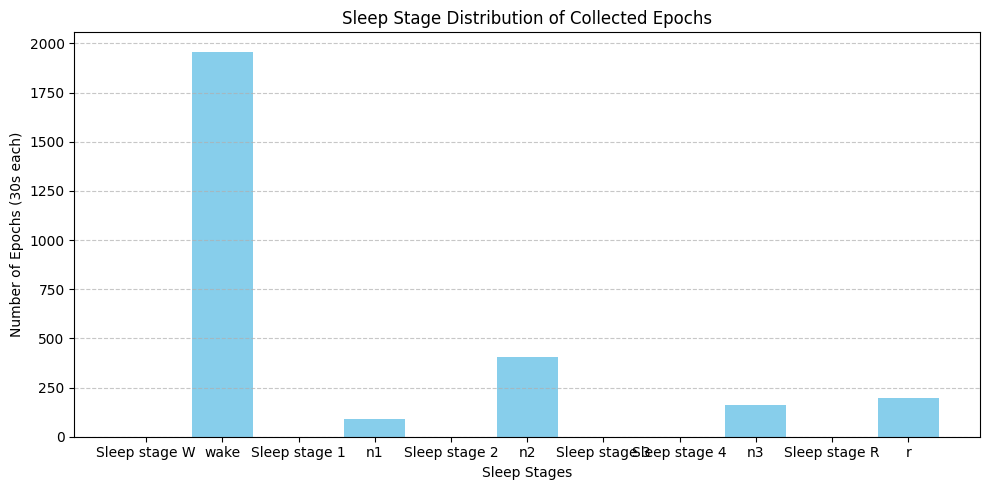

In [49]:
# 假设 raw_psg 已经被加载和预处理
# ... (你的 raw_psg 加载和预处理代码) ...

# 假设 SFREQ 和 EPOCH_DURATION 已经定义
# 例如:
SFREQ = 100 # 假设采样率
EPOCH_DURATION = 30 # 秒

# 定义睡眠阶段的映射，这需要与EDF文件中Hypnogram事件的描述一致
SLEEP_STAGES_MAP = {
    'Sleep stage W': 0, 'Sleep stage 1': 1, 'Sleep stage 2': 2, 'Sleep stage 3': 3,
    'Sleep stage 4': 3, 'Sleep stage R': 4, 'Sleep stage ?': -1, 'Movement time': -1,
    'wake': 0, 'n1': 1, 'n2': 2, 'n3': 3, 'r': 4
}


# --- 从 if raw_psg.annotations: 开始改写 ---
if raw_psg.annotations:
    # 修改这里，collected_epochs_params 将只包含 'start_sample', 'end_sample', 'stage'
    collected_epochs_params = [] 
    collected_labels = [] # 这个列表用于统计和绘图，内容仍然是数值型标签
    
    sfreq = raw_psg.info['sfreq']
    n_samples_per_epoch = int(EPOCH_DURATION * sfreq)

    total_annotated_duration = 0  # 存储所有有效标注的总时长
    processed_duration = 0        # 存储切片后实际收集的epoch总时长

    print(f"\n--- 处理Annotations ---")
    
    # 构建一个 event_id 映射，用于可视化标签
    event_id_for_plot = {name: SLEEP_STAGES_MAP[name] for name in SLEEP_STAGES_MAP if SLEEP_STAGES_MAP[name] != -1}
    # 从 event_id_for_plot 构建反向映射
    stage_to_id = {v: k for k, v in event_id_for_plot.items()}

    for ann in raw_psg.annotations:
        description = ann['description']
        onset_sec = ann['onset']
        duration_sec = ann['duration']
        
        # 映射到数值标签
        mapped_label_id = SLEEP_STAGES_MAP.get(description, -1)

        # 仅处理有效睡眠阶段的标注
        if mapped_label_id != -1:
            total_annotated_duration += duration_sec
            
            onset_sample = int(onset_sec * sfreq)
            duration_samples = int(duration_sec * sfreq)
            
            num_full_epochs = duration_samples // n_samples_per_epoch

            for i in range(num_full_epochs):
                start_current_epoch_sample = onset_sample + i * n_samples_per_epoch
                end_current_epoch_sample = start_current_epoch_sample + n_samples_per_epoch
                
                # 确保切片在原始数据范围内
                if end_current_epoch_sample <= raw_psg.n_times:
                    # 按照你要求的格式进行保存
                    collected_epochs_params.append({
                        'start_sample': np.int64(start_current_epoch_sample),
                        'end_sample': np.int64(end_current_epoch_sample),
                        'stage': np.str_(description) # 使用原始的description作为stage名称
                    })
                    collected_labels.append(mapped_label_id) # collected_labels仍存储数值标签
                    processed_duration += EPOCH_DURATION
                # else:
                #     print(f"警告: Epoch从 {start_current_epoch_sample/sfreq:.2f}s 起超出原始数据范围，已跳过。")
            
            # 剩余不足一个EPOCH_DURATION的将被自动跳过
            # ... (这些打印行可以根据需要保留或删除) ...

    lost_data_percentage = ( (total_annotated_duration - processed_duration) / total_annotated_duration ) * 100 \
                           if total_annotated_duration > 0 else 0

    print(f"\n收集到 {len(collected_epochs_params)} 个 {EPOCH_DURATION} 秒的有效睡眠阶段epochs。")
    print(f"总有效标注时长: {total_annotated_duration:.2f} 秒。")
    print(f"实际处理的有效epoch总时长: {processed_duration:.2f} 秒。")
    print(f"因标注过短或碎片化而被丢弃的有效标注数据比例: {lost_data_percentage:.2f}%")

    # 打印前几个 epoch 的格式以验证
    print("\n前5个收集到的epoch参数示例:")
    for i in range(min(5, len(collected_epochs_params))):
        print(collected_epochs_params[i])

    # 可视化睡眠阶段分布 (这部分逻辑不变，因为它依赖 collected_labels)
    stage_names_for_plot = [k for k, v in sorted(event_id_for_plot.items(), key=lambda item: item[1])]
    
    stage_counts = {name: 0 for name in stage_names_for_plot}
    for label_id in collected_labels:
        stage_name = stage_to_id.get(label_id)
        if stage_name:
            stage_counts[stage_name] += 1
            
    counts = [stage_counts[name] for name in stage_names_for_plot]

    plt.figure(figsize=(10, 5))
    plt.bar(stage_names_for_plot, counts, color='skyblue')
    plt.title('Sleep Stage Distribution of Collected Epochs')
    plt.xlabel('Sleep Stages')
    plt.ylabel(f'Number of Epochs ({EPOCH_DURATION}s each)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("警告: 未能从 raw_psg 对象中加载有效标注，无法提取睡眠阶段。")

# collected_epochs_params 现在就是你要求的格式
# collected_labels 仍然包含数值型标签，可以用于模型训练
epochs = collected_epochs_params


In [50]:

# --- 4. 重点：将PSG数据切分成30秒epochs并与标注对齐 ---

# 获取采样频率
sfreq = raw_psg.info['sfreq']
epoch_len_sec = 30
num_samples_per_epoch = int(sfreq * epoch_len_sec)

# 选择一个主要的EEG通道进行演示
target_eeg_channel = 'EEG Fpz-Cz' # 或者你找到的其他EEG通道
# 确保eeg_channels有被定义，例如:
eeg_channels = [ch for ch in raw_psg.ch_names if 'EEG' in ch] # 示例：如果eeg_channels列表没被定义


if target_eeg_channel not in raw_psg.ch_names:
    print(f"\n警告: 目标通道 '{target_eeg_channel}' 未在PSG文件中找到。尝试使用第一个可用的EEG通道。")
    if eeg_channels:
        target_eeg_channel = eeg_channels[0]
        print(f"使用通道: {target_eeg_channel}")
    else:
        print("错误: 未找到任何EEG通道，无法切分数据。")
        exit()

# 提取eeg_data**
eeg_data = raw_psg.get_data(picks=target_eeg_channel, start=0, stop=raw_psg.n_times)
# eeg_data 的形状现在应该是 (1, total_samples)
print(f"选定通道 '{target_eeg_channel}' 的数据形状: {eeg_data.shape}")



选定通道 'EEG Fpz-Cz' 的数据形状: (1, 8430000)


In [51]:
total_samples = raw_psg.n_times
total_duration_sec = total_samples / sfreq
print(f"正在处理通道: {target_eeg_channel}")
print(f"总EEG数据点数 ({target_eeg_channel}): {total_samples}")
print(f"基于EEG数据的总时长: {total_duration_sec:.2f} 秒")
# epoch_len_sec = 30 # 已经定义过了，无需重复
num_full_epochs_psg = int(total_duration_sec / epoch_len_sec)
print(f"PSG数据可切分为 {num_full_epochs_psg} 个 {epoch_len_sec} 秒的完整epoch。")

# 修正这里的变量名
# 注意：len(labels) 指的是从 Hypnogram 文件中提取的所有 30 秒标注的数量
# print(f"Hypnogram中共有 {len(labels)} 个标注epoch。")


正在处理通道: EEG Fpz-Cz
总EEG数据点数 (EEG Fpz-Cz): 8430000
基于EEG数据的总时长: 84300.00 秒
PSG数据可切分为 2810 个 30 秒的完整epoch。


In [52]:
# 这里 min_epochs 应该用来限制遍历 Hypnogram 标注的范围
# 而不是用来简单对齐 PSG 的固定30秒窗口
# **更严谨的对齐方式**
# 存储切分后的EEG片段和对应的标签
eeg_epochs = []
aligned_labels = []

# 存储PSG的所有30秒数据片段，以备后面精确对齐
psg_raw_epochs = []
for i in range(num_full_epochs_psg):
    start_s = i * num_samples_per_epoch
    end_s = (i + 1) * num_samples_per_epoch
    psg_raw_epochs.append(eeg_data[0, start_s:end_s])


# 现在我们遍历从 Hypnogram 中提取的 labels (这些是30秒的标注)
# 并且它们已经包含了 onset 信息 (尽管你在 labels 列表中没有直接存储)
# 假设你的 `epochs` 列表 (包含字典) 包含了 start_sample 信息
# 让我们使用之前构建的 `epochs` 列表来获取正确的起始样本和标签
# for loop 应该遍历你之前创建的 `epochs` 列表 (每个元素是一个字典)

# **重新设计循环，基于 Hypnogram 提取的具有开始时间的 epochs**
# `epochs` 列表的每个元素是 {'start_sample': ..., 'end_sample': ..., 'stage': ...}
# `labels` 列表的每个元素是 'Sleep stage X'
# 确保 `epochs` 和 `labels` 的长度和顺序是对应的

# 假设 `epochs` 列表是你之前生成的
# 循环 `epochs` 而不是 `range(min_epochs)`
print(f"考虑对齐后，Hypnogram标注的有效epoch数量为: {len(epochs)}") # 更新此行


考虑对齐后，Hypnogram标注的有效epoch数量为: 2810


In [53]:
for epoch_info in epochs: # `epochs` 是包含字典的列表，如 {'start_sample': ..., 'end_sample': ..., 'stage': ...}
    start_sample_hyp = epoch_info['start_sample']
    end_sample_hyp = epoch_info['end_sample']
    stage_label = epoch_info['stage']

    # 确保这个标注完全落在PSG数据的范围内
    if end_sample_hyp <= total_samples:
        # 提取当前标注对应的EEG数据片段
        epoch_data = eeg_data[0, start_sample_hyp:end_sample_hyp]
        # print(epoch_data)
        if epoch_data.shape[0] == num_samples_per_epoch: # 确保片段长度正确
            eeg_epochs.append(epoch_data)
            aligned_labels.append(stage_label) # 直接使用字典中的 stage_label
        # else: 如果长度不匹配，通常是因为原始标注duration不是30，但我们前面已经过滤了
        # print(f"警告: 标注epoch {stage_label} ({start_sample_hyp}-{end_sample_hyp}) 数据长度不匹配，跳过。
        # 预期 {num_samples_per_epoch} 个样本，实际 {epoch_data.shape[0]}。")
    # else:
        # print(f"警告: 标注epoch {stage_label} ({start_sample_hyp}-{end_sample_hyp}) 超出PSG数据范围，跳过。")

# print(eeg_epochs)
# print(aligned_labels)
print(f"\nepochs数量: {len(epochs)}")
print(f"\n最终对齐后，获得 {len(eeg_epochs)} 个EEG epoch与标注对应。")


epochs数量: 2810

最终对齐后，获得 2810 个EEG epoch与标注对应。


In [54]:
# 将列表转换为NumPy数组
eeg_epochs_array = np.array(eeg_epochs)
aligned_labels_array = np.array(aligned_labels)

print(f"\n最终切分并对齐的EEG epoch数量: {eeg_epochs_array.shape[0]}")
print(f"每个EEG epoch的形状: {eeg_epochs_array.shape[1]} (样本点数)")
print(f"对齐的标签数量: {aligned_labels_array.shape[0]}")



最终切分并对齐的EEG epoch数量: 2810
每个EEG epoch的形状: 3000 (样本点数)
对齐的标签数量: 2810


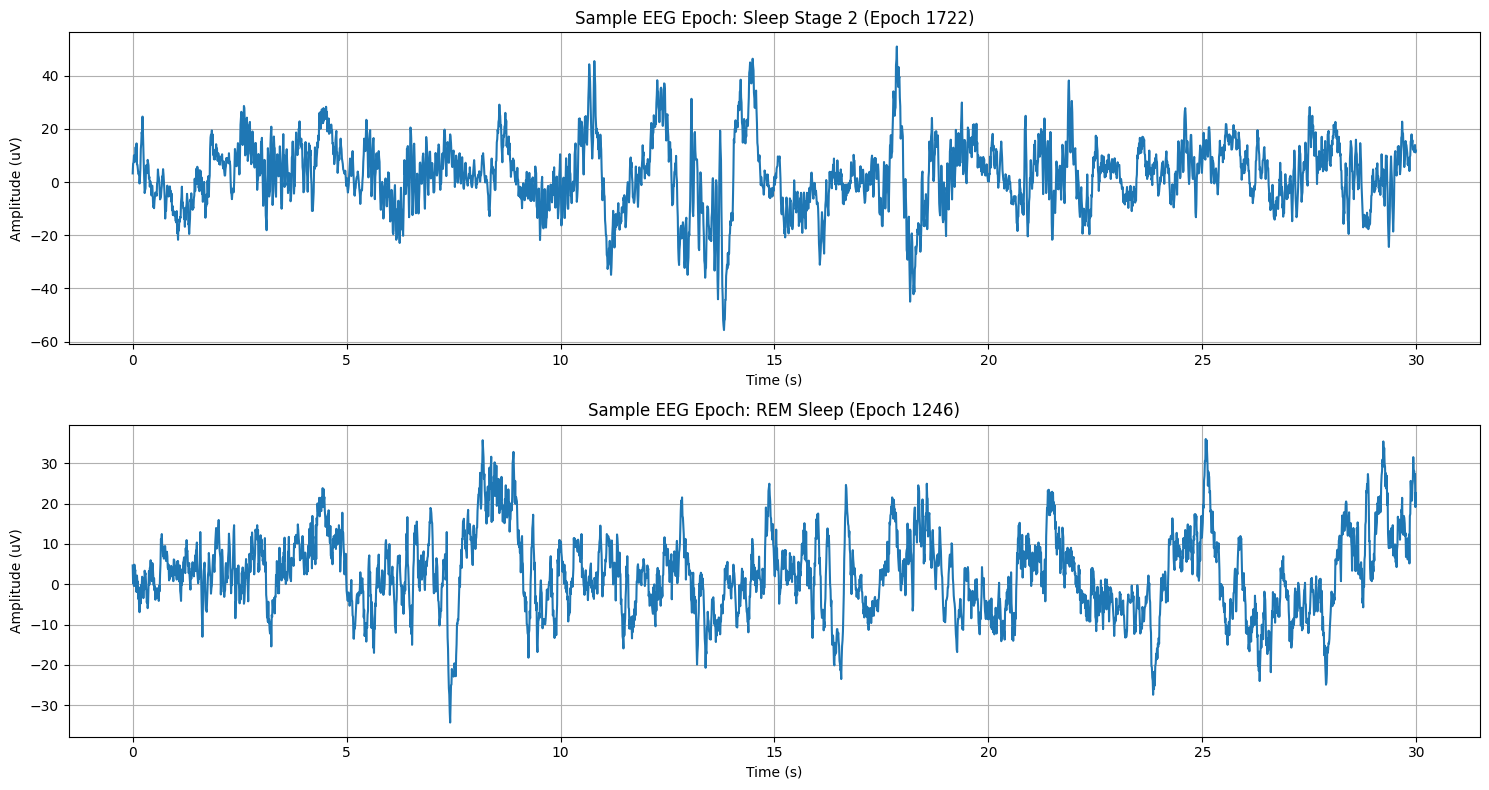

In [55]:
# 随机挑选一个N2和REM的EEG片段进行可视化
n2_indices = np.where(aligned_labels_array == 'Sleep stage 2')[0]
rem_indices = np.where(aligned_labels_array == 'Sleep stage R')[0]

plt.figure(figsize=(15, 8))

if len(n2_indices) > 0:
    random_n2_idx = np.random.choice(n2_indices)
    plt.subplot(2, 1, 1)
    # 使用 np.linspace 创建时间轴
    time_vec_sec = np.linspace(0, epoch_len_sec, num_samples_per_epoch, endpoint=False) # endpoint=False 确保时间点数量正确
    plt.plot(time_vec_sec, eeg_epochs_array[random_n2_idx] * 1e6)
    plt.title(f'Sample EEG Epoch: Sleep Stage 2 (Epoch {random_n2_idx+1})')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (uV)')
    plt.grid(True)
else:
    print("没有找到Sleep Stage 2的epoch进行可视化。")

if len(rem_indices) > 0:
    random_rem_idx = np.random.choice(rem_indices)
    plt.subplot(2, 1, 2)
    # 使用 np.linspace 创建时间轴
    time_vec_sec = np.linspace(0, epoch_len_sec, num_samples_per_epoch, endpoint=False)
    plt.plot(time_vec_sec, eeg_epochs_array[random_rem_idx] * 1e6)
    plt.title(f'Sample EEG Epoch: REM Sleep (Epoch {random_rem_idx+1})')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (uV)')
    plt.grid(True)
else:
    print("没有找到REM Sleep的epoch进行可视化。")

plt.tight_layout()
plt.show()



下面的代码单元将：

- 横轴使用整个记录的时间（秒），纵轴显示 EEG 电压（µV）。
- 根据 `raw_psg.annotations` 的 `onset`/`duration`（若 `duration` 为 0 则用相邻 onset 差值或记录结束推导）在图中用不同颜色高亮每个 sleep stage 的时间段。
- 为了绘图性能，会对信号进行下采样（默认最多绘制 200k 点）。

前提：在运行此单元前已执行加载 PSG 的单元，且存在 `raw_psg`（和可选的 `target_eeg_channel` / `eeg_data`）。

In [56]:
import matplotlib.patches as mpatches
from datetime import timedelta

# --- 确认并准备 EEG 数据 ---
if 'raw_psg' not in globals():
    raise RuntimeError('raw_psg 未定义，请先运行加载 PSG 的单元。')

sfreq = raw_psg.info['sfreq']
total_samples = raw_psg.n_times
total_duration_sec = total_samples / sfreq

# 获取或构造一维 EEG 信号（µV）
try:
    eeg_data
except NameError:
    try:
        picks = target_eeg_channel if 'target_eeg_channel' in globals() else None
        if picks is None or picks not in raw_psg.ch_names:
            picks = raw_psg.ch_names[0]
        eeg_data = raw_psg.get_data(picks=picks, start=0, stop=raw_psg.n_times)
    except Exception as e:
        raise RuntimeError(f'无法从 raw_psg 获取 EEG 数据: {e}')

eeg = eeg_data[0].astype(float) * 1e6  # µV
time = np.arange(total_samples) / sfreq

# 下采样以提高绘图性能（最多绘制 max_points 点）
max_points = 200000
step = max(1, int(total_samples / max_points))
time_ds = time[::step]
eeg_ds = eeg[::step]


In [57]:
import re
# 修正并取第一个/最后一个 非 'W' 标注的 start/end
ann = raw_psg.annotations
onsets = np.array(ann.onset, dtype=float)
raw_durs = np.array(ann.duration, dtype=float)
durations = raw_psg.annotations.duration

# 用相邻onset差值推导缺失的duration
derived = np.diff(np.append(onsets, total_duration_sec))
# 若 raw_durs 是 0 或 <=0 则用 derived 替代（保证长度一致）
durs = np.where(raw_durs > 0, raw_durs, derived[: len(onsets)])

# 检查 annotation 描述，和生成简短标签 stages
descs = np.array(ann.description, dtype=object)
def short_stage(desc):
    s = str(desc).lower().strip()
    # 精确匹配单字符标注或包含“sleep stage X”等形式
    if re.search(r'\bw\b', s) or 'wake' in s or 'awake' in s:
        return 'W'
    if re.search(r'\br\b', s) or 'rem' in s:
        return 'R'
    if 'stage 1' in s or s in ('1', 'n1'):
        return 'N1'
    if 'stage 2' in s or s in ('2', 'n2'):
        return 'N2'
    if 'stage 3' in s or 'stage 4' in s or 'n3' in s or 'sws' in s:
        return 'N3'
    if '?' in desc or 'unknown' in desc or 'undefined' in desc: return 'IGNORE' 
    return s  # 保留原描述以便调试

# 计算 starts / ends 如前（durs 已经用 derived 填充）
starts = onsets
ends = starts + durs

# 过滤：去掉 start >= total_duration，或 end <= start，或时长太短（例如 < 1s）
valid_mask = (starts < total_duration_sec) & (ends > starts + 1.0)
starts = starts[valid_mask]
ends = ends[valid_mask]
descs = descs[valid_mask]

# 重新生成 stages（使用上面的 short_stage）
stages = np.array([short_stage(d) for d in descs], dtype=object)
print("前10个标注阶段:", stages[:10])

# # 取非 W 的第一个/最后一个索引（若不存在回退
non_w_idx = np.where(stages != 'W') & (stages != 'IGNORE')[0]
print(f"非 'W' 阶段索引: {non_w_idx}")
# if len(non_w_idx) > 0:
#     sleep_onset = float(starts[non_w_idx[0]])
#     wake_time   = float(ends[non_w_idx[-2]])
#     print(f"First non-W stage at index {non_w_idx[0]}, time {sleep_onset:.1f} s")
#     print(f"Last non-W stage at index {non_w_idx[-1]}, time {wake_time:.1f} s")

def get_robust_sleep_boundaries(starts, ends, stages, total_duration_sec):
    """
    使用双指针收缩法，排除入睡前和醒来后的零星干扰，寻找主要睡眠区间。
    GAP_THRESHOLD: 判定为“非睡眠长间隔”的阈值
    MIN_SLEEP_LIMIT: 预期的最小睡眠跨度，默认6小时
    BUFFER_SEC: 在最终结果中，睡眠前后各增加的时间
    """
    # 参数定义
    GAP_THRESHOLD_FOR_BLOCK_SEPARATION = 1 * 3600  # 区分不同睡眠块的清醒间隔：1小时
    GAP_THRESHOLD_FOR_EDGE_CLEANING = 1800  # 清理块边缘的清醒间隔：30分钟
    MIN_SLEEP_BLOCK_DURATION = 3 * 3600 # 最短的有效睡眠块时长：3小时
    MIN_SLEEP_LIMIT_FOR_ROBUSTNESS = 6 * 3600 # 鲁棒性检查的最小睡眠跨度：6小时
    BUFFER_SEC = 1800 
    # 1. 过滤掉 'W' 和 'IGNORE' 阶段
    # 确保 stages 数组在外部已经被正确处理，例如 'sleep stage ?' 标记为 'IGNORE'
    valid_sleep_stage_mask = (stages != 'W') & (stages != 'IGNORE')
    
    # 获取这些有效睡眠阶段在原始 `starts` 数组中的索引
    non_w_original_indices = np.where(valid_sleep_stage_mask)[0]
    if len(non_w_original_indices) == 0:
        print("警告: 未找到任何有效的睡眠阶段 (非W且非IGNORE)。")
        return 0.0, total_duration_sec - 0.01
    # 2. 识别所有独立的睡眠块 (Sleep Blocks)
    sleep_blocks = [] # 存储每个睡眠块的 [(start_idx_in_non_w_original_indices, end_idx_in_non_w_original_indices)]
    current_block_start_idx = non_w_original_indices[0]
    
    for i in range(len(non_w_original_indices) - 1):
        idx_current = non_w_original_indices[i]
        idx_next = non_w_original_indices[i+1]
        
        # 计算当前有效睡眠阶段结束 到 下一个有效睡眠阶段开始 之间的清醒间隔
        gap = starts[idx_next] - ends[idx_current]
        
        if gap > GAP_THRESHOLD_FOR_BLOCK_SEPARATION:
            # 发现一个大间隔，这意味着一个新的睡眠块开始
            block_start = current_block_start_idx
            block_end = idx_current
            sleep_blocks.append((block_start, block_end))
            current_block_start_idx = idx_next
            
    # 添加最后一个睡眠块
    sleep_blocks.append((current_block_start_idx, non_w_original_indices[-1]))
    print(f"识别出 {len(sleep_blocks)} 个潜在睡眠块。")
    # 3. 计算每个睡眠块的持续时间并选择最长的
    longest_block = None
    max_block_duration = 0
    for block_start_orig_idx, block_end_orig_idx in sleep_blocks:
        block_onset = starts[block_start_orig_idx]
        block_offset = ends[block_end_orig_idx]
        block_duration = block_offset - block_onset
        if block_duration > max_block_duration and block_duration >= MIN_SLEEP_BLOCK_DURATION:
            max_block_duration = block_duration
            longest_block = (block_start_orig_idx, block_end_orig_idx)
    if longest_block is None:
        print(f"警告: 未找到持续时间超过 {MIN_SLEEP_BLOCK_DURATION / 3600:.1f} 小时的主要睡眠块。")
        # 如果没有找到足够长的主睡眠块，可以返回空或者整个数据的范围，取决于你的处理逻辑
        return 0.0, total_duration_sec - 0.01 
    # 4. 对选定的主睡眠块应用双指针收缩
    # 将 longest_block 的原始索引转换回其在 `non_w_original_indices` 中的相应位置
    # 这样可以兼容之前的双指针逻辑
    left_ptr_idx = np.where(non_w_original_indices == longest_block[0])[0][0]
    right_ptr_idx = np.where(non_w_original_indices == longest_block[1])[0][0]
    # 重新计算这个块的睡眠中心时间
    block_starts_for_center = starts[non_w_original_indices[left_ptr_idx:right_ptr_idx+1]]
    block_ends_for_center = ends[non_w_original_indices[left_ptr_idx:right_ptr_idx+1]]
    
    weighted_midpoints = (block_starts_for_center + block_ends_for_center) / 2
    weighted_durations = block_ends_for_center - block_starts_for_center
    if np.sum(weighted_durations) > 0:
        sleep_center_time = np.sum(weighted_midpoints * weighted_durations) / np.sum(weighted_durations)
    else:
        sleep_center_time = (block_starts_for_center[0] + block_ends_for_center[-1]) / 2
    # 执行收缩，类似于 get_robust_sleep_boundaries_v2 的逻辑
    while left_ptr_idx < right_ptr_idx:
        current_onset_candidate = starts[non_w_original_indices[left_ptr_idx]]
        current_offset_candidate = ends[non_w_original_indices[right_ptr_idx]]
        
        current_sleep_span = current_offset_candidate - current_onset_candidate
        
        if current_sleep_span <= MIN_SLEEP_LIMIT_FOR_ROBUSTNESS and (right_ptr_idx - left_ptr_idx <= 1):
            break
            
        changed = False
        
        # 左指针右移
        if left_ptr_idx + 1 <= right_ptr_idx:
            original_idx_current = non_w_original_indices[left_ptr_idx]
            original_idx_next_valid_sleep = non_w_original_indices[left_ptr_idx + 1]
            gap_duration = starts[original_idx_next_valid_sleep] - ends[original_idx_current]
            if gap_duration > GAP_THRESHOLD_FOR_EDGE_CLEANING:
                if starts[original_idx_next_valid_sleep] < sleep_center_time:
                    left_ptr_idx += 1
                    changed = True
                elif left_ptr_idx == np.where(non_w_original_indices == longest_block[0])[0][0]: # 如果是这个块的第一个有效睡眠段，允许移动
                    left_ptr_idx += 1
                    changed = True
        
        # 右指针左移
        if right_ptr_idx - 1 >= left_ptr_idx:
            original_idx_current = non_w_original_indices[right_ptr_idx]
            original_idx_prev_valid_sleep = non_w_original_indices[right_ptr_idx - 1]
            gap_duration = starts[original_idx_current] - ends[original_idx_prev_valid_sleep]
            if gap_duration > GAP_THRESHOLD_FOR_EDGE_CLEANING:
                if ends[original_idx_prev_valid_sleep] > sleep_center_time:
                    right_ptr_idx -= 1
                    changed = True
                elif right_ptr_idx == np.where(non_w_original_indices == longest_block[1])[0][0]: # 如果是这个块的最后一个有效睡眠段，允许移动
                    right_ptr_idx -= 1
                    changed = True
        
        if not changed:
            break
    final_onset = float(starts[non_w_original_indices[left_ptr_idx]])
    final_offset = float(ends[non_w_original_indices[right_ptr_idx]])
    
    final_onset = max(0.0, final_onset - BUFFER_SEC)
    final_offset = min(total_duration_sec - 0.01, final_offset + BUFFER_SEC)
        
    return final_onset, final_offset

sleep_onset, wake_time = get_robust_sleep_boundaries(starts, ends, stages, raw_psg.times[-1])


def fmt_hms(sec):
    return str(timedelta(seconds=int(sec)))

print(f"Sleep onset: {sleep_onset:.1f} s ({fmt_hms(sleep_onset)})")
print(f"Wake time: {wake_time:.1f} s ({fmt_hms(wake_time)})")

# 颜色映射（按出现顺序）
unique_stages = []
for s in stages:
    if s not in unique_stages:
        unique_stages.append(s)
cmap = plt.get_cmap('tab10')
color_map = {st: cmap(i % 10) for i, st in enumerate(unique_stages)}


前10个标注阶段: ['W' 'N1' 'N2' 'N1' 'N2' 'N3' 'N3' 'N3' 'N3' 'N3']
非 'W' 阶段索引: [[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
  1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
  1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 1 0
  0 1]]
识别出 1 个潜在睡眠块。
Sleep onset: 26190.0 s (7:16:30)
Wake time: 55470.0 s (15:24:30)


源数据标记汇总

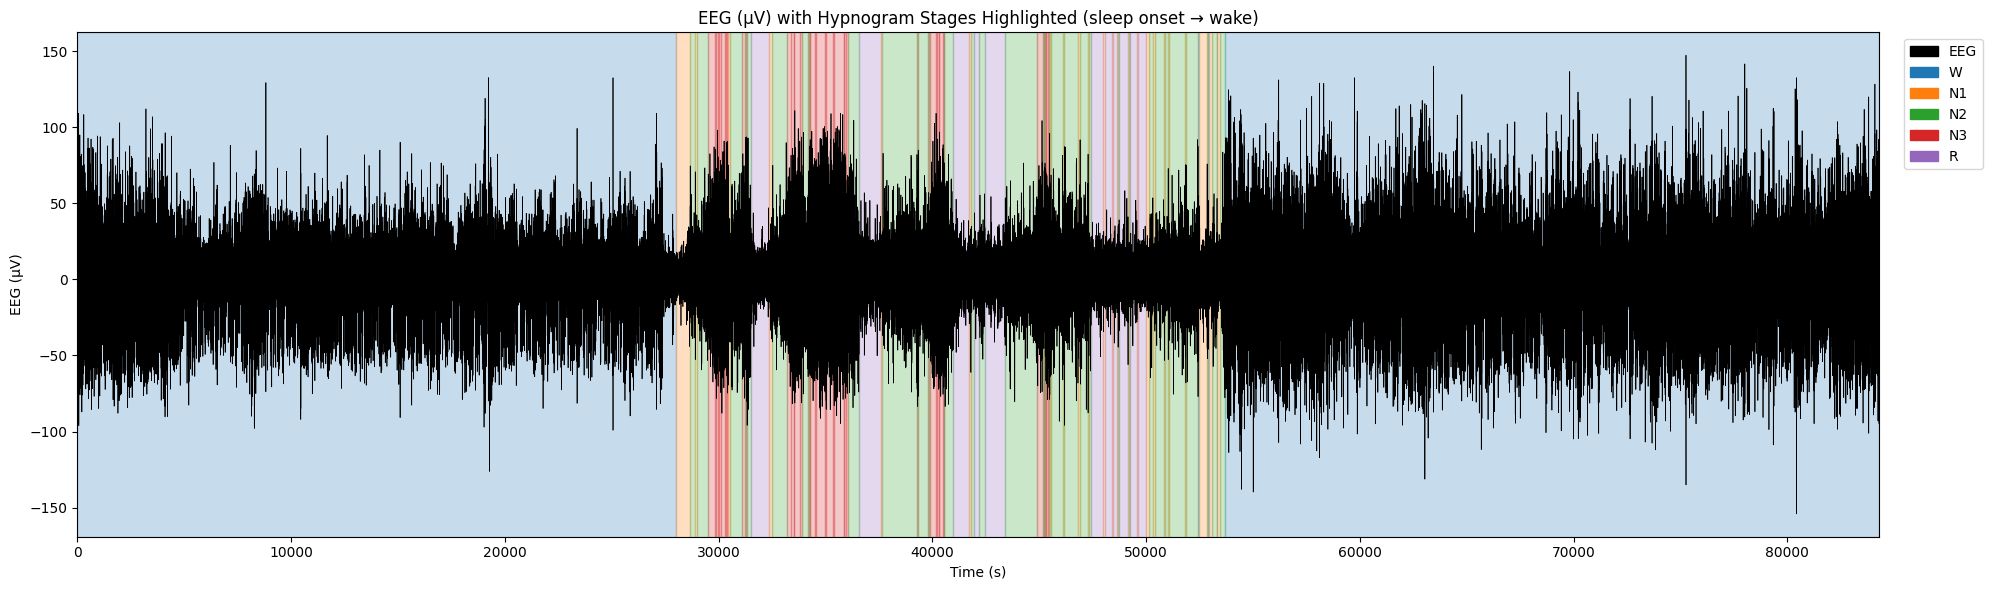

In [58]:
# --- 绘图 ---
fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(time_ds, eeg_ds, color='black', linewidth=0.5, label='EEG')

# 叠加标注区域（半透明）仅在入睡-醒来区间显示
for onset, dur, st in zip(onsets, durations, stages):
    start = float(onset)
    end = float(onset + dur) if dur > 0 else float(onset + 30.0)
    start = max(0.0, start)
    end = min(total_duration_sec, end)
    # if end <= start:
    #     continue
    # # 若标注与入睡-醒来区间无交集则跳过
    # if end <= sleep_onset or start >= wake_time:
    #     continue
    color = color_map.get(st, (0.8, 0.8, 0.8))
    ax.axvspan(start, end, color=color, alpha=0.25)

# 图例（EEG + 各 stage）
patches = [mpatches.Patch(color=color_map[s], label=s) for s in unique_stages]
ax.legend(handles=[mpatches.Patch(color='black', label='EEG')] + patches, bbox_to_anchor=(1.01, 1), loc='upper left')

# x1 = max(0.0, sleep_onset)
# x2 = min(total_duration_sec, wake_time)

x1 = 0
x2 = total_duration_sec

# 设置 x 轴为入睡到醒来
ax.set_xlim(x1, x2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('EEG (µV)')
ax.set_title('EEG (µV) with Hypnogram Stages Highlighted (sleep onset → wake)')
plt.tight_layout()
plt.show()


In [59]:
# # 配置：是否同时绘制 EEG 信号（False 则只显示标注）
# plot_eeg = False

# if 'raw_psg' not in globals():
#     raise RuntimeError('请先运行加载 PSG 的单元，确保 raw_psg 可用。')

# sfreq = raw_psg.info['sfreq']

# # 获取标注段：优先使用已有的 epochs（字典列表），否则用 annotations
# segments = []  # 每项 (start_sec, end_sec, stage_label)
# for e in epochs:
#     s = float(e['start_sample']) / sfreq
#     t = float(e['end_sample']) / sfreq
#     segments.append((s, t, e.get('stage', '')))

# # 可选：过滤掉无效/极短段
# segments = [(s, e, lab) for s, e, lab in segments if e > s + 0.5 and s < raw_psg.times[-1]]
# if len(segments) == 0:
#     raise RuntimeError('未找到有效的标注段 (segments 为空)。')

# # 如果绘 EEG：取首选通道的全记录并下采样以加速绘图
# if plot_eeg:
#     # 获取一维 EEG（µV）
#     try:
#         eeg_data
#     except NameError:
#         picks = target_eeg_channel if 'target_eeg_channel' in globals() else None
#         if picks is None or picks not in raw_psg.ch_names:
#             picks = raw_psg.ch_names[0]
#         eeg_data = raw_psg.get_data(picks=picks, start=0, stop=raw_psg.n_times)
#     eeg = eeg_data[0].astype(float) * 1e6
#     time = np.arange(eeg.size) / sfreq
#     max_points = 200000
#     step = max(1, int(eeg.size / max_points))
#     time_ds, eeg_ds = time[::step], eeg[::step]

# # 绘图
# fig, ax = plt.subplots(figsize=(18, 5))
# if plot_eeg:
#     ax.plot(time_ds, eeg_ds, color='black', linewidth=0.5, label='EEG')

# # 画标注区间
# for s, e, lab in segments:
#     color = color_map.get(lab, (0.8, 0.8, 0.8))
#     ax.axvspan(s, e, color=color, alpha=0.35)

# # 图例：只展示 stage（和 EEG 可选）
# patches = [mpatches.Patch(color=color_map[s], label=s) for s in unique_stages]
# handles = []
# if plot_eeg:
#     handles.append(mpatches.Patch(color='black', label='EEG'))
# handles.extend(patches)
# ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left')

# ax.set_xlim(sleep_onset, wake_time)
# ax.set_xlabel('Time (s)')
# ax.set_ylabel('EEG (µV)' if plot_eeg else '')
# ax.set_title('Annotation spans (by stage)')
# plt.tight_layout()
# plt.show()


In [60]:
import mne
import numpy as np
from scipy import signal
from tqdm import tqdm

def preprocess_sleep_edf_official(edf_file, annotation_file):
    """
    官方推荐的预处理流程
    参考: DeepSleepNet (2017) + U-Sleep (2021)
    """
    # 1. 读取 EDF 文件
    raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
    
    # 2. 选择 Fpz-Cz 通道（Sleep-EDF 推荐）
    raw.pick_channels(['EEG Fpz-Cz'])
    
    # 3. 重采样到 100 Hz（DeepSleepNet 标准）
    raw.resample(100)
    
    # 4. 带通滤波 0.3-35 Hz
    raw.filter(0.3, 35, method='fir', fir_design='firwin')
    
    # 5. 获取数据
    data = raw.get_data()[0]  # shape: (n_samples,)
    
    # 6. 读取标注
    annotations = mne.read_annotations(annotation_file)
    
    # 7. 映射标注到 AASM 5 分类
    label_map = {
        'Sleep stage W': 0,
        'Sleep stage 1': 1,
        'Sleep stage 2': 2,
        'Sleep stage 3': 3,
        'Sleep stage 4': 3,  # AASM 合并 S3 和 S4
        'Sleep stage R': 4,
        'Sleep stage ?': -1,
        'Movement time': -1
    }
    
    # 8. 按 30 秒切分 epoch
    sampling_rate = 100
    epoch_length = 30  # seconds
    samples_per_epoch = sampling_rate * epoch_length  # 3000
    
    num_epochs = len(data) // samples_per_epoch
    
    X = []
    y = []
    
    for i in range(num_epochs):
        # 提取数据
        epoch_data = data[i * samples_per_epoch : (i+1) * samples_per_epoch]
        
        # 提取标签（取 epoch 中点时刻的标签）
        epoch_time = (i + 0.5) * epoch_length
        label = -1
        for ann_idx, onset in enumerate(annotations.onset):
            if onset <= epoch_time < onset + annotations.duration[ann_idx]:
                label_str = annotations.description[ann_idx]
                label = label_map.get(label_str, -1)
                break
        
        # 9. Z-score 归一化（每个 epoch 独立）
        epoch_normalized = (epoch_data - np.mean(epoch_data)) / (np.std(epoch_data) + 1e-8)
        
        X.append(epoch_normalized)
        y.append(label)
    
    return np.array(X), np.array(y)

# 使用示例

X, y = preprocess_sleep_edf_official(
    'sleep-edf/sleep-cassette/SC4001E0-PSG.edf',
    'sleep-edf/sleep-cassette/SC4001EC-Hypnogram.edf'
)

print(f"Data shape: {X.shape}")  # (num_epochs, 3000)
print(f"Label distribution: {np.bincount(y[y >= 0])}")


C:\Users\Eason\AppData\Local\Temp\ipykernel_42916\3077216889.py:12: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\Eason\AppData\Local\Temp\ipykernel_42916\3077216889.py:12: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
C:\Users\Eason\AppData\Local\Temp\ipykernel_42916\3077216889.py:12: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Sampling frequency of the instance is already 100.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 1101 samples (11.010 s)

Data shape: (2650, 3000)
Label distribution: [1997   58  250  220  125]
